### logistic_regression

In this notebook, we attempt to predict nomination-worthy novels using a logistic classifier

In [103]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [104]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [105]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyPastNomineeSimilarityScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        # ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])
            ],
)

We shall use **walk-forward nested time series cross-validation**.

In [122]:
from walkforward_cv import walk_forward

windows = walk_forward(books_tt)


In [107]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

model = Pipeline([
    ('preprocess', feature_preprocessing),
    ('lr', LogisticRegression(l1_ratio=0, class_weight='balanced', max_iter=1000))
])

books_tt['years_since_last_nomination'] = books_tt['years_since_last_nomination'].fillna(99)

In [108]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.metrics import precision_score, ndcg_score
from sklearn.metrics import recall_score

cv_data = []



for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()

    year = book_val['release_year'].mode().values

    model.fit(book_train[features], book_train['target'])

    scores = model.predict_proba(book_val[features])[:, 1]

    ypred = (scores > 0.5).astype(int)

    book_val['predicted'] = ypred

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year, 'f1_score': f1score, 'recall': recall, 'precision': precision})


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.2922141779148585
STD of f1 score across folds:  0.06891404320592567


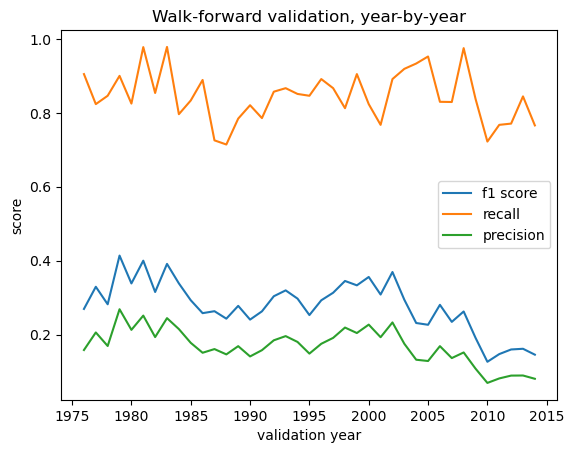

In [ ]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

<Axes: >

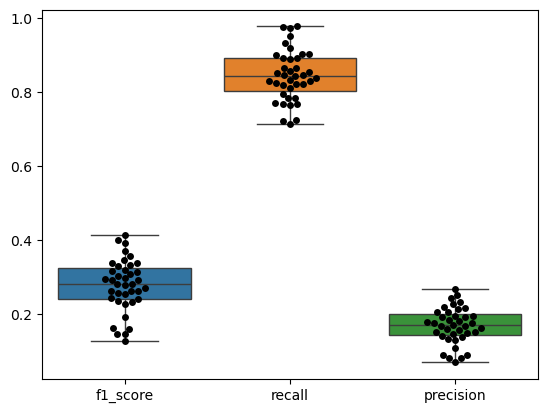

In [ ]:
import seaborn as sns


ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')


Let us look at the most important features.

In [ ]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

coefs = model.named_steps['lr'].coef_[0] 

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefs)
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                             Feature  Importance
5                 tag_similarity__cohort_similiarity   11.388424
6         nominee_similarity__past_winner_similarity    9.838262
2     numerical_scaling__years_since_last_nomination    0.801864
1                numerical_scaling__author_num_books    0.677823
3  numerical_scaling__publisher_historical_nomina...    0.399085
0         numerical_scaling__Total_Awards_Previously    0.379856
4           numerical_scaling__publisher_cohort_size    0.099769


This is very different from the XGB scaler! It does not seem to rely a lot on total past awards etc, but more on cohort similarity and past winner similarity.

Let's try to do a grid search to maximize f1-score.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import scipy as sp

param_search = {
    'lr__C': sp.stats.loguniform(1e-3, 1e2),
    'lr__l1_ratio': [0, 1],
    'lr__solver': ['liblinear'],
    'lr__class_weight': ['balanced', None],
}

# we have our folds earlier, just need to turn them to cv form 
# which wants indices. reuse walkforward function but this time with indices


cv_splits = []
years = np.sort(books_tt['release_year'].unique())

num_years = len(years)
step = 1
initial_size = 5

for i in range(initial_size, num_years - step + 1):
    data_start = 0
    data_end = i
    val_start = data_end
    val_end = val_start + step


    train_years = years[data_start:data_end]
    val_years = years[val_start:val_end]

    window_idx = books_tt.index[books_tt['release_year'].isin(train_years)].to_numpy()
    val_idx = books_tt.index[books_tt['release_year'].isin(val_years)].to_numpy()

    cv_splits.append((window_idx, val_idx))

search = RandomizedSearchCV(
    model,
    param_distributions=param_search,
    n_iter=30,
    cv=cv_splits,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=2
)


In [ ]:
search.fit(books_tt[features], books_tt['target'])


Fitting 39 folds for each of 30 candidates, totalling 1170 fits
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.4s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.2s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; tot

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END lr__C=0.0019517224641449498, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.2s
[CV] END lr__C=0.006026889128682512, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   2.8s
[CV] END lr__C=0.0019517224641449498, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.2s
[CV] END lr__C=0.0019517224641449498, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0019517224641449498, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.2s
[CV] END lr__C=0.006026889128682512, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   3.1s
[CV] END lr__C=0.0019517224641449498, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.2s
[CV] END lr__C=0.0019517224641449498, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0019517224641449498, lr__class_we

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'lr__C': <scipy.stats....t 0x36a0d8a40>, 'lr__class_weight': ['balanced', None], 'lr__l1_ratio': [0, 1], 'lr__solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can 

In [ ]:
print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

Best params: {'lr__C': np.float64(0.5414413211338525), 'lr__class_weight': None, 'lr__l1_ratio': 0, 'lr__solver': 'liblinear'}
Best CV score: 0.4445257580583019


In [ ]:
results = pd.DataFrame(search.cv_results_)
results = results.sort_values('rank_test_score')
cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']
results[cols].head()


,rank_test_score,mean_test_score,std_test_score,params
24,1,0.444526,0.093265,"{'lr__C': 0.5414413211338525, 'lr__class_weigh..."
4,2,0.444520,0.093155,"{'lr__C': 1.0129197956845732, 'lr__class_weigh..."
27,3,0.444470,0.093048,"{'lr__C': 0.9761125443110458, 'lr__class_weigh..."
10,4,0.442953,0.090777,"{'lr__C': 1.1462107403425035, 'lr__class_weigh..."
8,5,0.442399,0.097708,"{'lr__C': 0.033205591037519584, 'lr__class_wei..."


In [ ]:
results = results.sort_values('std_test_score')
cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']
results[cols].head()


,rank_test_score,mean_test_score,std_test_score,params
19,21,0.420111,0.083150,"{'lr__C': 2.6373339933815254, 'lr__class_weigh..."
1,20,0.422460,0.084773,"{'lr__C': 4.5705630998014515, 'lr__class_weigh..."
28,25,0.391129,0.086962,"{'lr__C': 0.0027698899227562817, 'lr__class_we..."
21,29,0.380458,0.087067,"{'lr__C': 0.0014857392806279248, 'lr__class_we..."
26,8,0.440567,0.087409,"{'lr__C': 49.830438374949125, 'lr__class_weigh..."


Let's try that best model with the best pr_auc and try and find the best threshold to maximize f1.

In [123]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.metrics import precision_score, ndcg_score, average_precision_score
from sklearn.metrics import recall_score

cv_data = []

model = Pipeline([
    ('preprocess', feature_preprocessing),
    ('lr', LogisticRegression(l1_ratio=0, class_weight=None, max_iter=1000, solver= 'liblinear', C=0.5414413211338525))
])

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()

    year = book_val['release_year'].mode().values

    model.fit(book_train[features], book_train['target'])

    scores = model.predict_proba(book_val[features])[:, 1]

    ypred = (scores > 0.5).astype(int)

    book_val['predicted'] = ypred

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = precision_score(book_val['target'], book_val['predicted'].values)
    pr_auc = average_precision_score(book_val['target'], scores)

    precisions, recalls, thresholds = precision_recall_curve(book_val['target'], scores)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-10)
    best_idx = f1s[:-1].argmax()

    cv_data.append({'fold': num, "val_year": year, 'best_threshold': thresholds[best_idx], 'best_f1': f1s[best_idx], 'best_precision': precisions[best_idx], 'best_recall': recalls[best_idx]})

    # cv_data.append({'fold': num, "val_year": year, 'f1_score': f1score, 'recall': recall, 'precision': precision, 'pr_auc': pr_auc})

In [124]:
cv_result = pd.DataFrame(cv_data)

<Axes: >

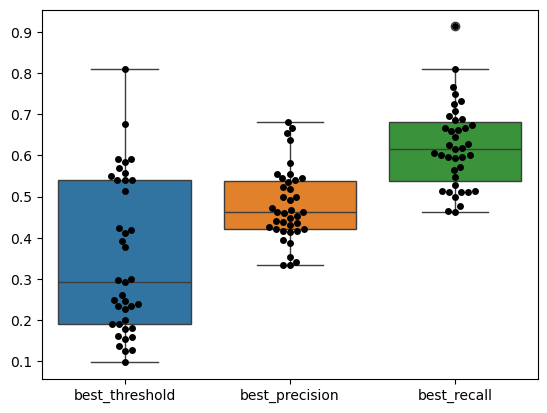

In [125]:
ax = sns.boxplot(data=cv_result[['best_threshold', 'best_precision', 'best_recall']])
sns.swarmplot(data=cv_result[['best_threshold', 'best_precision', 'best_recall']], ax=ax, color='black')

In [130]:
book_val[['title', 'author', 'predicted', 'target']][book_val['predicted'] == 1].groupby('target').count()

,title,author,predicted
target,,,
False,36,36,36
True,28,28,28


Great, the spread in threshold is huge (:

Let us pick the threshold which does best on the most folds.

In [113]:
windows = walk_forward(books_tt)


cv_data = []

model = Pipeline([
    ('preprocess', feature_preprocessing),
    ('lr', LogisticRegression(l1_ratio=0, class_weight=None, max_iter=1000, solver= 'liblinear', C=0.5414413211338525))
])

thresholds = np.arange(0.3, 0.7, 0.05)
for thresh in thresholds:
    f1scores = []
    recalls = []
    precisions = []
    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1]

        book_train = book_train.copy()
        book_val = book_val.copy()

        year = book_val['release_year'].mode().values

        model.fit(book_train[features], book_train['target'])

        scores = model.predict_proba(book_val[features])[:, 1]

        ypred = (scores > thresh).astype(int)

        book_val['predicted'] = ypred

        f1score = f1_score(book_val['target'], book_val['predicted'].values)
        recall = recall_score(book_val['target'], book_val['predicted'].values)
        precision = precision_score(book_val['target'], book_val['predicted'].values)
        f1scores.append(f1score)
        recalls.append(recall)
        precisions.append(precision)

    print('threshold: {} -- mean f1: {}, mean recall: {}, mean precision: {}'.format(thresh, np.mean(f1scores), np.mean(recalls), np.mean(precisions)))


    # cv_data.append({'fold': num, "val_year": year, 'threshold': thresh, 'f1_score': f1score, 'recall': recall, 'precision': precision, 'pr_auc': pr_auc})

threshold: 0.3 -- mean f1: 0.46764591158138985, mean recall: 0.5623243940655878, mean precision: 0.428225676353499
threshold: 0.35 -- mean f1: 0.4560095195817512, mean recall: 0.5154399942992027, mean precision: 0.4445656620499533
threshold: 0.39999999999999997 -- mean f1: 0.4518419966662266, mean recall: 0.4783478846204092, mean precision: 0.4774964382350147
threshold: 0.44999999999999996 -- mean f1: 0.4324223608117831, mean recall: 0.43044493073137347, mean precision: 0.5007862753729696
threshold: 0.49999999999999994 -- mean f1: 0.4067471091934585, mean recall: 0.3815242628519575, mean precision: 0.528862978950307
threshold: 0.5499999999999999 -- mean f1: 0.3769416199290751, mean recall: 0.33484658597970934, mean precision: 0.5469973154555269
threshold: 0.5999999999999999 -- mean f1: 0.34370958431813475, mean recall: 0.2882817713276847, mean precision: 0.5793324784981593
threshold: 0.6499999999999999 -- mean f1: 0.3036167444492002, mean recall: 0.24388258980666022, mean precision: 0.

This is not great! Recall is dropping faster than precision is rising. 
How does this change for previous nominated authors vs new authors?

In [115]:
windows = walk_forward(books_tt[~books_tt['new_author']])


cv_data = []

model = Pipeline([
    ('preprocess', feature_preprocessing),
    ('lr', LogisticRegression(l1_ratio=0, class_weight=None, max_iter=1000, solver= 'liblinear', C=0.5414413211338525))
])

thresholds = np.arange(0.3, 0.7, 0.05)
for thresh in thresholds:
    f1scores = []
    recalls = []
    precisions = []
    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1]

        book_train = book_train.copy()
        book_val = book_val.copy()

        year = book_val['release_year'].mode().values

        model.fit(book_train[features], book_train['target'])

        scores = model.predict_proba(book_val[features])[:, 1]

        ypred = (scores > thresh).astype(int)

        book_val['predicted'] = ypred

        f1score = f1_score(book_val['target'], book_val['predicted'].values)
        recall = recall_score(book_val['target'], book_val['predicted'].values)
        precision = precision_score(book_val['target'], book_val['predicted'].values)
        f1scores.append(f1score)
        recalls.append(recall)
        precisions.append(precision)

    print('threshold: {} -- mean f1: {}, mean recall: {}, mean precision: {}'.format(thresh, np.mean(f1scores), np.mean(recalls), np.mean(precisions)))


    # cv_data.append({'fold': num, "val_year": year, 'threshold': thresh, 'f1_score': f1score, 'recall': recall, 'precision': precision, 'pr_auc': pr_auc})

threshold: 0.3 -- mean f1: 0.4740253268090659, mean recall: 0.5967785506978053, mean precision: 0.42394375431764036
threshold: 0.35 -- mean f1: 0.4719682065370962, mean recall: 0.5533208219304455, mean precision: 0.45081966430233084
threshold: 0.39999999999999997 -- mean f1: 0.46633180834240634, mean recall: 0.5118021000526009, mean precision: 0.4815698696171472
threshold: 0.44999999999999996 -- mean f1: 0.43786486575898625, mean recall: 0.44689478873196264, mean precision: 0.5045453138015271
threshold: 0.49999999999999994 -- mean f1: 0.41939198974603503, mean recall: 0.40432672729589175, mean precision: 0.533186208980648
threshold: 0.5499999999999999 -- mean f1: 0.3896482705306706, mean recall: 0.3550379382820098, mean precision: 0.5612527457920155
threshold: 0.5999999999999999 -- mean f1: 0.3521735942752302, mean recall: 0.3021323306531325, mean precision: 0.5810775809199221
threshold: 0.6499999999999999 -- mean f1: 0.314463481606196, mean recall: 0.2568073698830441, mean precision: 

In [116]:
windows = walk_forward(books_tt[books_tt['new_author']])


cv_data = []

model = Pipeline([
    ('preprocess', feature_preprocessing),
    ('lr', LogisticRegression(l1_ratio=0, class_weight=None, max_iter=1000, solver= 'liblinear', C=0.5414413211338525))
])

thresholds = np.arange(0.3, 0.7, 0.05)
for thresh in thresholds:
    f1scores = []
    recalls = []
    precisions = []
    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1]

        book_train = book_train.copy()
        book_val = book_val.copy()

        year = book_val['release_year'].mode().values

        model.fit(book_train[features], book_train['target'])

        scores = model.predict_proba(book_val[features])[:, 1]

        ypred = (scores > thresh).astype(int)

        book_val['predicted'] = ypred

        f1score = f1_score(book_val['target'], book_val['predicted'].values)
        recall = recall_score(book_val['target'], book_val['predicted'].values)
        precision = precision_score(book_val['target'], book_val['predicted'].values)
        f1scores.append(f1score)
        recalls.append(recall)
        precisions.append(precision)

    print('threshold: {} -- mean f1: {}, mean recall: {}, mean precision: {}'.format(thresh, np.mean(f1scores), np.mean(recalls), np.mean(precisions)))


    # cv_data.append({'fold': num, "val_year": year, 'threshold': thresh, 'f1_score': f1score, 'recall': recall, 'precision': precision, 'pr_auc': pr_auc})

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


threshold: 0.3 -- mean f1: 0.2955488955488956, mean recall: 0.27987382987382986, mean precision: 0.45128205128205134


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

threshold: 0.35 -- mean f1: 0.2252358752358752, mean recall: 0.1993894993894994, mean precision: 0.3487179487179487


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

threshold: 0.39999999999999997 -- mean f1: 0.22578347578347577, mean recall: 0.19511599511599512, mean precision: 0.36367521367521366


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

threshold: 0.44999999999999996 -- mean f1: 0.21017501017501017, mean recall: 0.17374847374847374, mean precision: 0.358974358974359


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

threshold: 0.49999999999999994 -- mean f1: 0.2056980056980057, mean recall: 0.1686202686202686, mean precision: 0.37606837606837606


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

threshold: 0.5499999999999999 -- mean f1: 0.2227920227920228, mean recall: 0.1686202686202686, mean precision: 0.40598290598290593


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

threshold: 0.5999999999999999 -- mean f1: 0.2227920227920228, mean recall: 0.1686202686202686, mean precision: 0.40598290598290593


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

threshold: 0.6499999999999999 -- mean f1: 0.21495726495726494, mean recall: 0.1600732600732601, mean precision: 0.41025641025641024


In [120]:
book_val[book_val['predicted'] == 1]

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi,predicted
68850,73398,73398,Shipstar,"Gregory Benford, Larry Niven",2014,tor,"['sf', 'alien', 'adventur', 'space', 'fantasi']",False,True,04,...,0,0,0,0,0,0,0,0,0,1
73687,78235,78235,Ancillary Sword,Ann Leckie,2014,orbit,"['reflect', 'sad', 'diverse charact', 'plot dr...",True,True,Unknown,...,0,0,0,0,1,0,0,0,0,1
